# Modèle XGBoost

## Importation des bibliothèques

In [190]:
%pip install scikit-learn xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## Social Media

### Chargement des données

In [191]:
df = pd.read_csv("BDD_initial/Students Social Media Addiction.csv")

print(df.shape)
print(df['Addicted_Score'].describe())
df.head()

(705, 13)
count    705.000000
mean       6.436879
std        1.587165
min        2.000000
25%        5.000000
50%        7.000000
75%        8.000000
max        9.000000
Name: Addicted_Score, dtype: float64


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [192]:
print('Types de données')
print(df.dtypes)
print('\nValeurs manquantes')
print(df.isnull().sum())
print('\nStatistiques descriptives')
df.describe()

Types de données
Student_ID                        int64
Age                               int64
Gender                           object
Academic_Level                   object
Country                          object
Avg_Daily_Usage_Hours           float64
Most_Used_Platform               object
Affects_Academic_Performance     object
Sleep_Hours_Per_Night           float64
Mental_Health_Score               int64
Relationship_Status              object
Conflicts_Over_Social_Media       int64
Addicted_Score                    int64
dtype: object

Valeurs manquantes
Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score       

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,353.000000,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,203.660256,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,1.000000,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,177.000000,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,353.000000,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,529.000000,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,705.000000,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


### Prétraitement des données

In [193]:
df_ml = df.copy()
df_ml = df_ml.drop(columns=['Student_ID'])

categorical_cols = df_ml.select_dtypes(include='object').columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    label_encoders[col] = le
    print(f'  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

df_ml.head()

  Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
  Academic_Level: {'Graduate': np.int64(0), 'High School': np.int64(1), 'Undergraduate': np.int64(2)}
  Country: {'Afghanistan': np.int64(0), 'Albania': np.int64(1), 'Andorra': np.int64(2), 'Argentina': np.int64(3), 'Armenia': np.int64(4), 'Australia': np.int64(5), 'Austria': np.int64(6), 'Azerbaijan': np.int64(7), 'Bahamas': np.int64(8), 'Bahrain': np.int64(9), 'Bangladesh': np.int64(10), 'Belarus': np.int64(11), 'Belgium': np.int64(12), 'Bhutan': np.int64(13), 'Bolivia': np.int64(14), 'Bosnia': np.int64(15), 'Brazil': np.int64(16), 'Bulgaria': np.int64(17), 'Canada': np.int64(18), 'Chile': np.int64(19), 'China': np.int64(20), 'Colombia': np.int64(21), 'Costa Rica': np.int64(22), 'Croatia': np.int64(23), 'Cyprus': np.int64(24), 'Czech Republic': np.int64(25), 'Denmark': np.int64(26), 'Ecuador': np.int64(27), 'Egypt': np.int64(28), 'Estonia': np.int64(29), 'Finland': np.int64(30), 'France': np.int64(31), 'Georgia': np.int64(32), 'G

,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,19,0,2,10,5.2,1,1,6.5,6,1,3,8
1,22,1,0,39,2.1,7,0,7.5,8,2,0,3
2,20,0,2,102,6.0,6,1,5.0,5,0,4,9
3,18,1,1,101,3.0,11,0,7.0,7,2,1,4
4,21,1,0,18,4.5,0,1,6.0,6,1,2,7


### Entrainement du modèle

In [194]:
X = df_ml.drop(columns=['Addicted_Score'])
y = df_ml['Addicted_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Ensemble d'entraînement :", X_train.shape[0], "lignes (80%)")
print("Ensemble de test        :", X_test.shape[0],  "lignes (20%)")
print("\nFeatures utilisées", len(X.columns), ":", list(X.columns))

Ensemble d'entraînement : 564 lignes (80%)
Ensemble de test        : 141 lignes (20%)

Features utilisées 11 : ['Age', 'Gender', 'Academic_Level', 'Country', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Relationship_Status', 'Conflicts_Over_Social_Media']


In [195]:
xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print("Modèle entraîné !")

Modèle entraîné !


### Évaluation des modèle

In [196]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=== Résultats — Modèle XGBoost ===")
print(f"  MAE  (erreur absolue moyenne)       : {mae:.3f}")
print(f"  RMSE (racine erreur quadratique)    : {rmse:.3f}")
print(f"  R²   (coefficient de détermination) : {r2:.3f}")
print(f"\n  Le modèle explique {r2*100:.1f}% de la variance du score")

=== Résultats — Modèle XGBoost ===
  MAE  (erreur absolue moyenne)       : 0.066
  RMSE (racine erreur quadratique)    : 0.192
  R²   (coefficient de détermination) : 0.985

  Le modèle explique 98.5% de la variance du score


### Visualisations

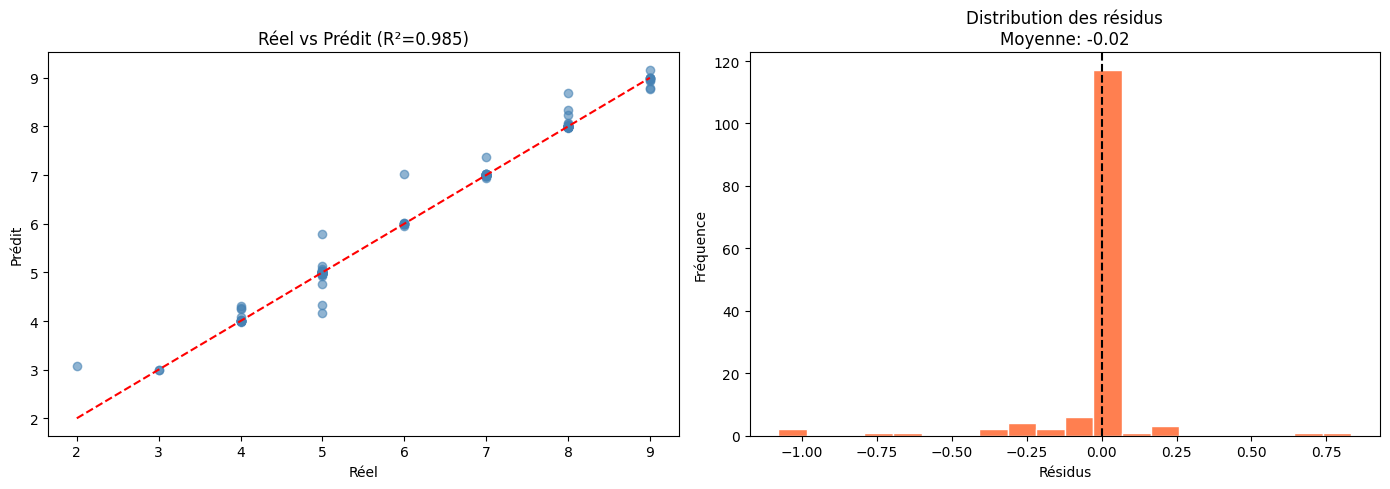

In [197]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prédictions vs Valeurs Réelles
axes[0].scatter(y_test, y_pred, alpha=0.6, color='steelblue')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axes[0].set(xlabel='Réel', ylabel='Prédit', title=f'Réel vs Prédit (R²={r2:.3f})')

# Distribution des résidus
residus = y_test - y_pred
axes[1].hist(residus, bins=20, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set(xlabel='Résidus', ylabel='Fréquence',
            title=f'Distribution des résidus\nMoyenne: {residus.mean():.2f}')

plt.tight_layout()
plt.show()

In [198]:
cv_scores = cross_val_score(xgb, X, y, cv=5, scoring='r2')

print("=== Validation Croisée (5-fold) ===")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: R² = {score:.4f}")
print(f"\n  R² moyen   : {cv_scores.mean():.4f}")
print(f"  Écart-type : {cv_scores.std():.4f}")

=== Validation Croisée (5-fold) ===
  Fold 1: R² = 0.9214
  Fold 2: R² = 0.8853
  Fold 3: R² = 0.9923
  Fold 4: R² = 0.9873
  Fold 5: R² = 0.9352

  R² moyen   : 0.9443
  Écart-type : 0.0406


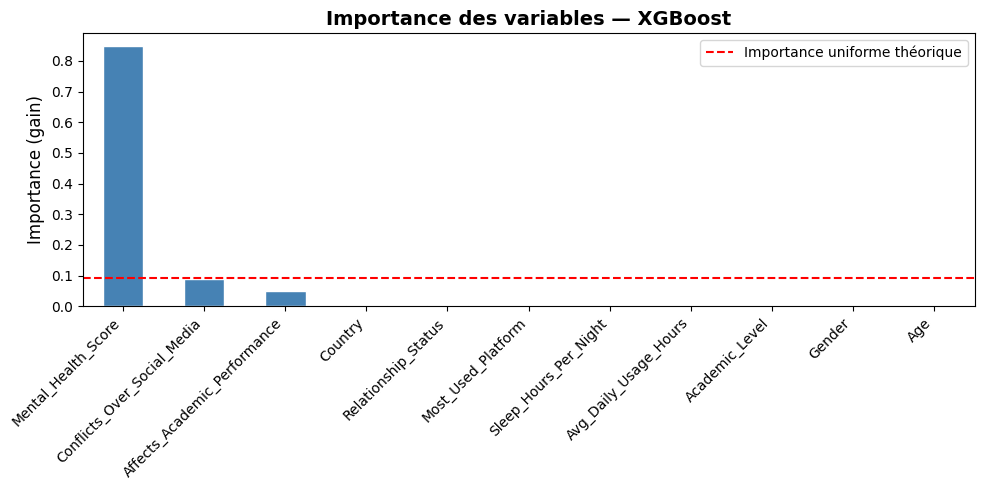

In [199]:
importances = pd.Series(
    xgb.feature_importances_, index=X.columns
).sort_values(ascending=False)

importances.plot(kind='bar', figsize=(10, 5), color='steelblue', edgecolor='white')
plt.ylabel('Importance (gain)', fontsize=12)
plt.title('Importance des variables — XGBoost', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.axhline(
    y=1 / len(X.columns), color='red', linestyle='--',
    label='Importance uniforme théorique'
)
plt.legend()
plt.tight_layout()
plt.show()

In [200]:
param_grid = {
    'n_estimators' : [50, 100, 200],
    'max_depth'    : [None, 5, 10, 20],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample'    : [0.8, 1.0, None]
}

grid_search = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid, cv=5, scoring='r2', n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

comparaison = pd.DataFrame({
    'Base'    : {'R²' : round(r2, 3), 'MAE': round(mae, 3)},
    'Optimisé': {
        'R²' : round(r2_score(y_test, y_pred_best), 3),
        'MAE': round(mean_absolute_error(y_test, y_pred_best), 3)
    }
})
comparaison['Δ'] = comparaison['Optimisé'] - comparaison['Base']
print(f"Meilleurs paramètres : {grid_search.best_params_}")
display(comparaison)

Meilleurs paramètres : {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


,Base,Optimisé,Δ
R²,0.985,0.979,-0.006
MAE,0.066,0.087,0.021


## Drogues

### Chargement des données


In [201]:
df = pd.read_csv('BDD_initial/addiction_population_data.csv')

print(df.shape)
df.head()

(3000, 27)


,id,name,age,gender,country,city,education_level,employment_status,annual_income_usd,marital_status,...,has_health_issues,mental_health_status,exercise_frequency,diet_quality,sleep_hours,bmi,social_support,therapy_history,addict_smoke,addict_drink
0,1,Michael Bates,66,Other,Yemen,Martinmouth,Secondary,Student,45595,Married,...,True,Good,Daily,Average,5.6,22.4,NaN,Current,0,0
1,2,Brian Thompson,29,Male,Saudi Arabia,Harperhaven,Primary,Self-Employed,145842,Single,...,False,Poor,Weekly,Good,6.7,24.1,Moderate,NaN,1,0
2,3,Steven Little,75,Male,Togo,Chanport,Postgraduate,Unemployed,162480,Single,...,True,Good,Never,Good,6.2,22.2,Weak,NaN,1,0
3,4,Michael Mathews,35,Other,Togo,North Cory,University,Unemployed,16023,In a relationship,...,False,Average,Daily,Good,7.2,25.5,Moderate,Current,0,0
4,5,Nicholas Sanchez,38,Female,Morocco,Danielberg,College,Self-Employed,62933,In a relationship,...,True,Poor,Weekly,Good,8.5,31.2,Weak,Past,0,0


In [202]:
print('Types de données')
print(df.dtypes)
print('\nValeurs manquantes')
print(df.isnull().sum())
print('\nStatistiques descriptives')
df.describe()

Types de données
id                             int64
name                          object
age                            int64
gender                        object
country                       object
city                          object
education_level               object
employment_status             object
annual_income_usd              int64
marital_status                object
children_count                 int64
smokes_per_day                 int64
drinks_per_week                int64
age_started_smoking            int64
age_started_drinking           int64
attempts_to_quit_smoking       int64
attempts_to_quit_drinking      int64
has_health_issues               bool
mental_health_status          object
exercise_frequency            object
diet_quality                  object
sleep_hours                  float64
bmi                          float64
social_support                object
therapy_history               object
addict_smoke                   int64
addict_drink         

,id,age,annual_income_usd,children_count,smokes_per_day,drinks_per_week,age_started_smoking,age_started_drinking,attempts_to_quit_smoking,attempts_to_quit_drinking,sleep_hours,bmi,addict_smoke,addict_drink
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,46.654333,98904.178000,2.453667,10.034000,5.002333,24.365667,24.525333,4.440333,4.542000,6.470400,25.170133,0.422333,0.036667
std,866.169729,18.740880,57288.035963,1.704354,3.108386,2.214037,8.707309,8.679121,2.835334,2.866992,1.495878,5.013345,0.494013,0.187973
min,1.000000,15.000000,560.000000,0.000000,2.000000,0.000000,10.000000,10.000000,0.000000,0.000000,1.500000,9.100000,0.000000,0.000000
25%,750.750000,31.000000,49336.000000,1.000000,8.000000,3.000000,17.000000,17.000000,2.000000,2.000000,5.475000,21.900000,0.000000,0.000000
50%,1500.500000,47.000000,98616.500000,2.000000,10.000000,5.000000,24.000000,25.000000,4.000000,5.000000,6.500000,25.200000,0.000000,0.000000
75%,2250.250000,63.000000,148622.750000,4.000000,12.000000,6.000000,32.000000,32.000000,7.000000,7.000000,7.500000,28.400000,1.000000,0.000000
max,3000.000000,79.000000,199951.000000,5.000000,21.000000,14.000000,39.000000,39.000000,9.000000,9.000000,12.600000,43.900000,1.000000,1.000000


### Prétraitement des données

In [203]:
df_ml = df.copy()
df_ml = df_ml.drop(columns=['id', 'name', 'country', 'city'])

categorical_cols = df_ml.select_dtypes(include='object').columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    label_encoders[col] = le
    print(f'  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print('\nAperçu après encodage :')
df_ml.head()

  gender: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
  education_level: {'College': np.int64(0), 'High School': np.int64(1), 'Postgraduate': np.int64(2), 'Primary': np.int64(3), 'Secondary': np.int64(4), 'University': np.int64(5), 'nan': np.int64(6)}
  employment_status: {'Employed': np.int64(0), 'Retired': np.int64(1), 'Self-Employed': np.int64(2), 'Student': np.int64(3), 'Unemployed': np.int64(4)}
  marital_status: {'Divorced': np.int64(0), 'In a relationship': np.int64(1), 'Married': np.int64(2), 'Single': np.int64(3), 'Widowed': np.int64(4)}
  mental_health_status: {'Average': np.int64(0), 'Good': np.int64(1), 'Poor': np.int64(2)}
  exercise_frequency: {'Daily': np.int64(0), 'Never': np.int64(1), 'Rarely': np.int64(2), 'Weekly': np.int64(3)}
  diet_quality: {'Average': np.int64(0), 'Good': np.int64(1), 'Poor': np.int64(2)}
  social_support: {'Moderate': np.int64(0), 'Strong': np.int64(1), 'Weak': np.int64(2), 'nan': np.int64(3)}
  therapy_history: {'Current'

,age,gender,education_level,employment_status,annual_income_usd,marital_status,children_count,smokes_per_day,drinks_per_week,age_started_smoking,...,has_health_issues,mental_health_status,exercise_frequency,diet_quality,sleep_hours,bmi,social_support,therapy_history,addict_smoke,addict_drink
0,66,2,4,3,45595,2,3,5,4,12,...,True,1,0,0,5.6,22.4,3,0,0,0
1,29,1,3,2,145842,3,4,11,3,11,...,False,2,3,1,6.7,24.1,0,2,1,0
2,75,1,2,4,162480,3,5,13,4,18,...,True,1,1,1,6.2,22.2,2,2,1,0
3,35,2,5,4,16023,1,3,7,4,37,...,False,0,0,1,7.2,25.5,0,0,0,0
4,38,0,0,2,62933,1,0,8,2,20,...,True,2,3,1,8.5,31.2,2,1,0,0


In [204]:
cols_to_exclude = ['smokes_per_day', 'drinks_per_week', 'addict_smoke', 'addict_drink']
X = df_ml.drop(columns=cols_to_exclude)

y_smoke = df_ml['smokes_per_day']
y_drink = df_ml['drinks_per_week']

print(f"Features utilisées ({len(X.columns)}) : {list(X.columns)}")
print(f"\nDistribution smokes_per_day :\n{y_smoke.describe()}")
print(f"\nDistribution drinks_per_week :\n{y_drink.describe()}")

Features utilisées (19) : ['age', 'gender', 'education_level', 'employment_status', 'annual_income_usd', 'marital_status', 'children_count', 'age_started_smoking', 'age_started_drinking', 'attempts_to_quit_smoking', 'attempts_to_quit_drinking', 'has_health_issues', 'mental_health_status', 'exercise_frequency', 'diet_quality', 'sleep_hours', 'bmi', 'social_support', 'therapy_history']

Distribution smokes_per_day :
count    3000.000000
mean       10.034000
std         3.108386
min         2.000000
25%         8.000000
50%        10.000000
75%        12.000000
max        21.000000
Name: smokes_per_day, dtype: float64

Distribution drinks_per_week :
count    3000.000000
mean        5.002333
std         2.214037
min         0.000000
25%         3.000000
50%         5.000000
75%         6.000000
max        14.000000
Name: drinks_per_week, dtype: float64


In [205]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y_smoke, test_size=0.2, random_state=42
)

print(f"Entraînement : {X_train_s.shape[0]} lignes (80%)")
print(f"Test         : {X_test_s.shape[0]} lignes (20%)")

Entraînement : 2400 lignes (80%)
Test         : 600 lignes (20%)


In [206]:
xgb_smoke = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_smoke.fit(X_train_s, y_train_s)
y_pred_s = xgb_smoke.predict(X_test_s)

mae_s  = mean_absolute_error(y_test_s, y_pred_s)
rmse_s = np.sqrt(mean_squared_error(y_test_s, y_pred_s))
r2_s   = r2_score(y_test_s, y_pred_s)

print("=== Résultats — smokes_per_day ===")
print(f"  MAE  : {mae_s:.3f}")
print(f"  RMSE : {rmse_s:.3f}")
print(f"  R²   : {r2_s:.3f}")
print(f"\n  Le modèle explique {r2_s*100:.1f}% de la variance")

=== Résultats — smokes_per_day ===
  MAE  : 2.592
  RMSE : 3.298
  R²   : -0.082

  Le modèle explique -8.2% de la variance


In [207]:
cv_s = cross_val_score(xgb_smoke, X, y_smoke, cv=5, scoring='r2')

print("=== Validation Croisée (5-fold) — smokes_per_day ===")
for i, score in enumerate(cv_s, 1):
    print(f"  Fold {i}: R² = {score:.4f}")
print(f"\n  R² moyen   : {cv_s.mean():.4f}")
print(f"  Écart-type : {cv_s.std():.4f}")

=== Validation Croisée (5-fold) — smokes_per_day ===
  Fold 1: R² = -0.1160
  Fold 2: R² = -0.1460
  Fold 3: R² = -0.1392
  Fold 4: R² = -0.1155
  Fold 5: R² = -0.1018

  R² moyen   : -0.1237
  Écart-type : 0.0164


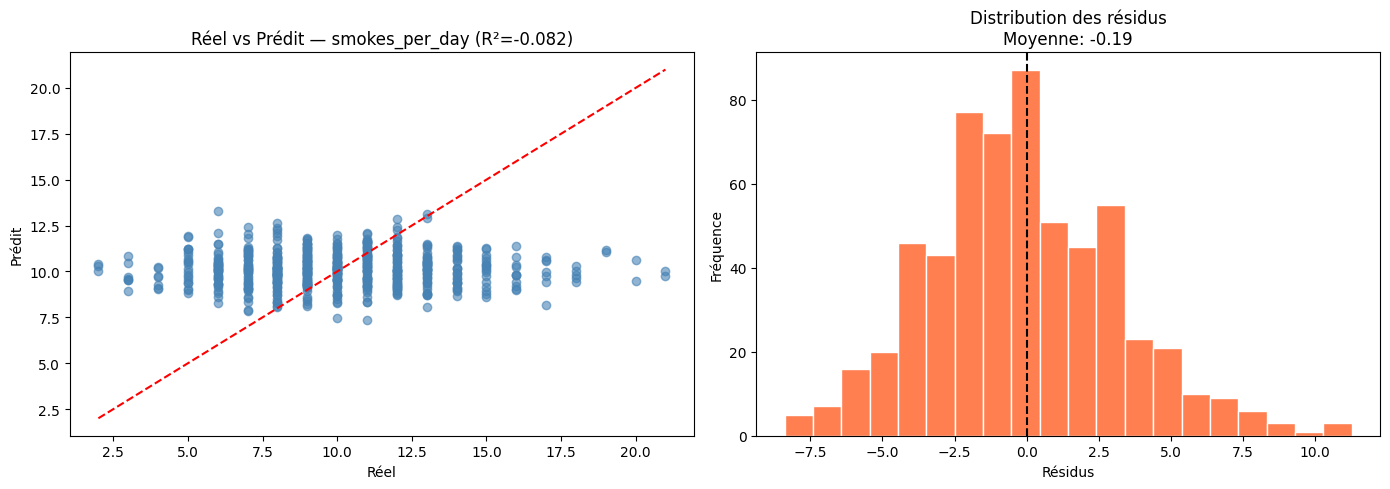

In [208]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_s, y_pred_s, alpha=0.6, color='steelblue')
axes[0].plot([y_smoke.min(), y_smoke.max()], [y_smoke.min(), y_smoke.max()], 'r--')
axes[0].set(xlabel='Réel', ylabel='Prédit',
            title=f'Réel vs Prédit — smokes_per_day (R²={r2_s:.3f})')

residus_s = y_test_s - y_pred_s
axes[1].hist(residus_s, bins=20, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set(xlabel='Résidus', ylabel='Fréquence',
            title=f'Distribution des résidus\nMoyenne: {residus_s.mean():.2f}')

plt.tight_layout()
plt.show()

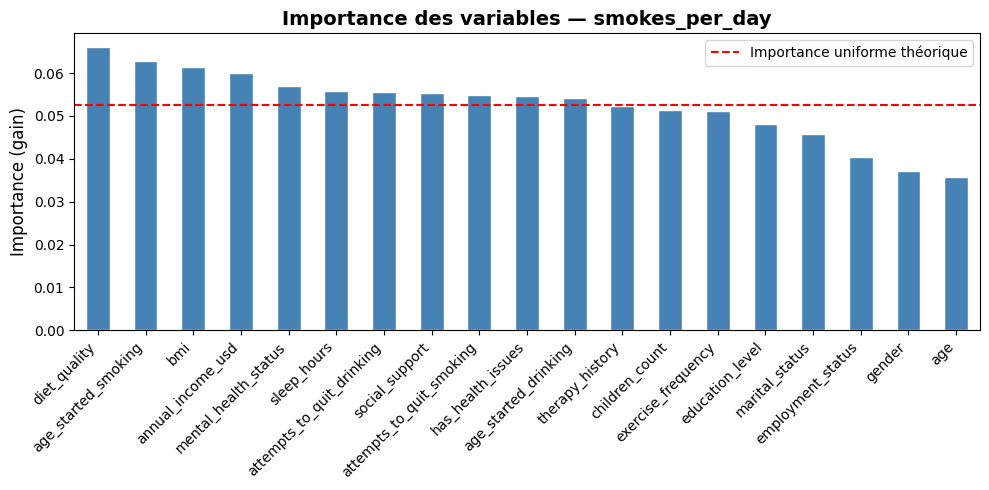

In [209]:
importances_s = pd.Series(
    xgb_smoke.feature_importances_, index=X.columns
).sort_values(ascending=False)

importances_s.plot(kind='bar', figsize=(10, 5), color='steelblue', edgecolor='white')
plt.ylabel('Importance (gain)', fontsize=12)
plt.title('Importance des variables — smokes_per_day', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=1 / len(X.columns), color='red', linestyle='--', label='Importance uniforme théorique')
plt.legend()
plt.tight_layout()
plt.show()

In [210]:
param_grid = {
    'n_estimators' : [50, 100, 200],
    'max_depth'    : [3, 5, 6, 10],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample'    : [0.8, 1.0]
}

grid_s = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid, cv=5, scoring='r2', n_jobs=-1
)
grid_s.fit(X_train_s, y_train_s)

best_xgb_s = grid_s.best_estimator_
y_pred_s_best = best_xgb_s.predict(X_test_s)

comparaison_s = pd.DataFrame({
    'Base'    : {'R²': round(r2_s, 3), 'MAE': round(mae_s, 3)},
    'Optimisé': {
        'R²' : round(r2_score(y_test_s, y_pred_s_best), 3),
        'MAE': round(mean_absolute_error(y_test_s, y_pred_s_best), 3)
    }
})
comparaison_s['Δ'] = comparaison_s['Optimisé'] - comparaison_s['Base']
print(f"Meilleurs paramètres : {grid_s.best_params_}")
display(comparaison_s)

Meilleurs paramètres : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}


,Base,Optimisé,Δ
R²,-0.082,-0.019,0.063
MAE,2.592,2.515,-0.077


#### Prédiction du nombre de verres par semaine

In [211]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X, y_drink, test_size=0.2, random_state=42
)

print(f"Entraînement : {X_train_d.shape[0]} lignes (80%)")
print(f"Test         : {X_test_d.shape[0]} lignes (20%)")

Entraînement : 2400 lignes (80%)
Test         : 600 lignes (20%)


In [212]:
xgb_drink = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_drink.fit(X_train_d, y_train_d)
y_pred_d = xgb_drink.predict(X_test_d)

mae_d  = mean_absolute_error(y_test_d, y_pred_d)
rmse_d = np.sqrt(mean_squared_error(y_test_d, y_pred_d))
r2_d   = r2_score(y_test_d, y_pred_d)

print("=== Résultats — drinks_per_week ===")
print(f"  MAE  : {mae_d:.3f}")
print(f"  RMSE : {rmse_d:.3f}")
print(f"  R²   : {r2_d:.3f}")
print(f"\n  Le modèle explique {r2_d*100:.1f}% de la variance")

=== Résultats — drinks_per_week ===
  MAE  : 1.880
  RMSE : 2.363
  R²   : -0.098

  Le modèle explique -9.8% de la variance


In [213]:
cv_d = cross_val_score(xgb_drink, X, y_drink, cv=5, scoring='r2')

print("=== Validation Croisée (5-fold) — drinks_per_week ===")
for i, score in enumerate(cv_d, 1):
    print(f"  Fold {i}: R² = {score:.4f}")
print(f"\n  R² moyen   : {cv_d.mean():.4f}")
print(f"  Écart-type : {cv_d.std():.4f}")

=== Validation Croisée (5-fold) — drinks_per_week ===
  Fold 1: R² = -0.1251
  Fold 2: R² = -0.1169
  Fold 3: R² = -0.0865
  Fold 4: R² = -0.1264
  Fold 5: R² = -0.1246

  R² moyen   : -0.1159
  Écart-type : 0.0151


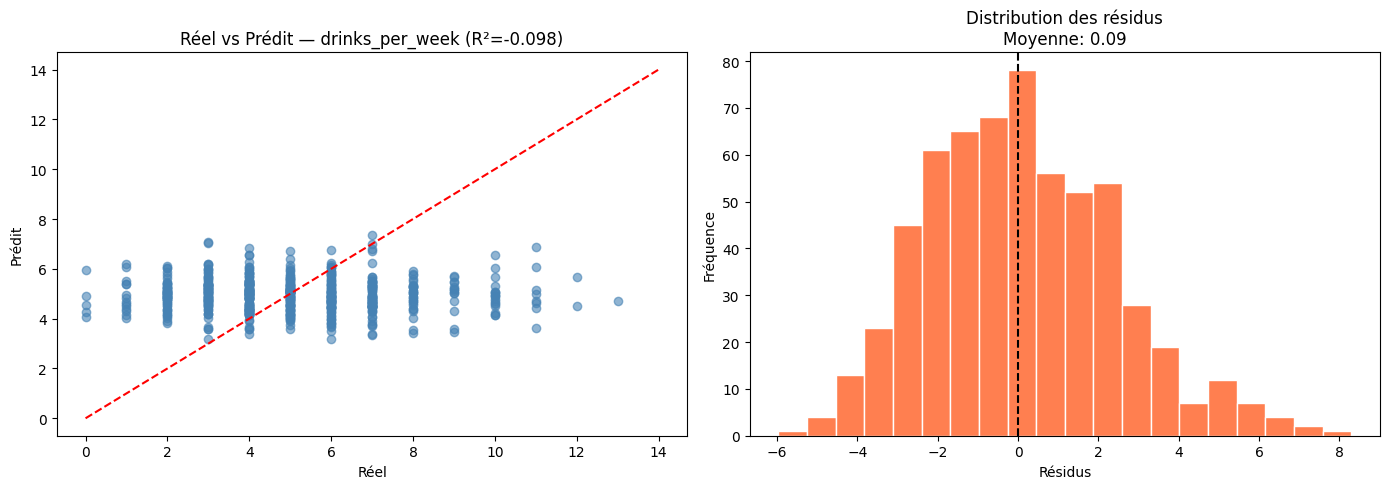

In [214]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_d, y_pred_d, alpha=0.6, color='steelblue')
axes[0].plot([y_drink.min(), y_drink.max()], [y_drink.min(), y_drink.max()], 'r--')
axes[0].set(xlabel='Réel', ylabel='Prédit',
            title=f'Réel vs Prédit — drinks_per_week (R²={r2_d:.3f})')

residus_d = y_test_d - y_pred_d
axes[1].hist(residus_d, bins=20, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set(xlabel='Résidus', ylabel='Fréquence',
            title=f'Distribution des résidus\nMoyenne: {residus_d.mean():.2f}')

plt.tight_layout()
plt.show()

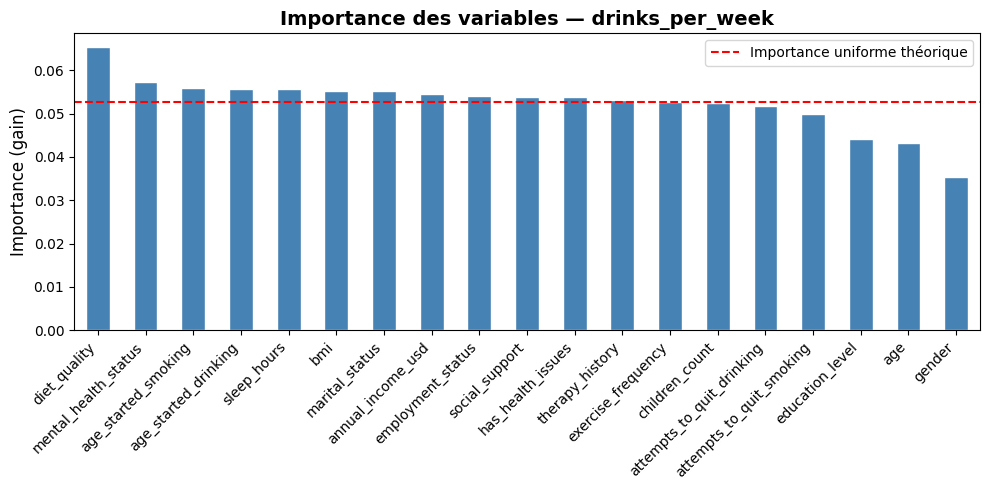

In [215]:
importances_d = pd.Series(
    xgb_drink.feature_importances_, index=X.columns
).sort_values(ascending=False)

importances_d.plot(kind='bar', figsize=(10, 5), color='steelblue', edgecolor='white')
plt.ylabel('Importance (gain)', fontsize=12)
plt.title('Importance des variables — drinks_per_week', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=1 / len(X.columns), color='red', linestyle='--', label='Importance uniforme théorique')
plt.legend()
plt.tight_layout()
plt.show()

In [216]:
grid_d = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid, cv=5, scoring='r2', n_jobs=-1
)
grid_d.fit(X_train_d, y_train_d)

best_xgb_d = grid_d.best_estimator_
y_pred_d_best = best_xgb_d.predict(X_test_d)

comparaison_d = pd.DataFrame({
    'Base'    : {'R²': round(r2_d, 3), 'MAE': round(mae_d, 3)},
    'Optimisé': {
        'R²' : round(r2_score(y_test_d, y_pred_d_best), 3),
        'MAE': round(mean_absolute_error(y_test_d, y_pred_d_best), 3)
    }
})
comparaison_d['Δ'] = comparaison_d['Optimisé'] - comparaison_d['Base']
print(f"Meilleurs paramètres : {grid_d.best_params_}")
display(comparaison_d)

Meilleurs paramètres : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50, 'subsample': 1.0}


,Base,Optimisé,Δ
R²,-0.098,-0.019,0.079
MAE,1.880,1.802,-0.078


,MAE,RMSE,R²
smokes_per_day,2.592,3.298,-0.082
drinks_per_week,1.880,2.363,-0.098


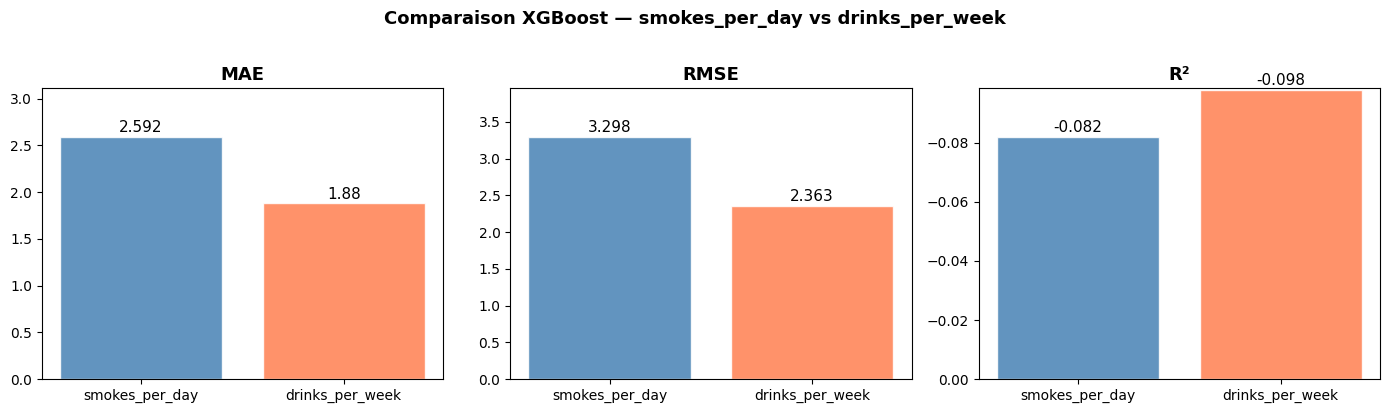

In [217]:
comparaison_finale = pd.DataFrame({
    'smokes_per_day' : {'MAE': round(mae_s, 3), 'RMSE': round(rmse_s, 3), 'R²': round(r2_s, 3)},
    'drinks_per_week': {'MAE': round(mae_d, 3), 'RMSE': round(rmse_d, 3), 'R²': round(r2_d, 3)}
}).T

display(comparaison_finale)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R²']):
    vals = comparaison_finale[metric]
    ax.bar(vals.index, vals.values,
           color=['steelblue', 'coral'], edgecolor='white', alpha=0.85)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, max(vals.values) * 1.2)
    for i, v in enumerate(vals.values):
        ax.text(i, v + max(vals.values)*0.02, str(round(v, 3)), ha='center', fontsize=11)

plt.suptitle('Comparaison XGBoost — smokes_per_day vs drinks_per_week',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Résultats obtenus

| Modèle | MAE | RMSE | R² |
|---|---|---|---|
| XGBoost — smokes_per_day | 2.592 | 3.298 | -0.082 |
| XGBoost — drinks_per_week | 1.880 | 2.363 | -0.098 |

## Addiction Mobile

### Chargement des données

In [218]:
df = pd.read_csv('BDD_initial/mobile_addiction_data.csv', sep='\t')
df['Daily_Screen_Time_Hours'] = df['Daily_Screen_Time_Hours'].str.replace(',', '.').astype(float)
print(df.shape)
print(df['Daily_Screen_Time_Hours'].describe())
df.head()

(3000, 35)
count    3000.000000
mean        5.984397
std         2.018142
min        -0.500000
25%         4.597500
50%         5.980000
75%         7.302500
max        12.870000
Name: Daily_Screen_Time_Hours, dtype: float64


,User_ID,Country,Age,Gender,Occupation,Education_Level,Income_USD,Daily_Screen_Time_Hours,Phone_Unlocks_Per_Day,Social_Media_Usage_Hours,...,Internet_Connection_Type,Primary_Device_Brand,Has_Screen_Time_Management_App,Self_Reported_Addiction_Level,Monthly_Data_Usage_GB,Has_Night_Mode_On,Age_First_Phone,Push_Notifications_Per_Day,Tech_Savviness_Score,Addiction_screen
0,1,India,32,Male,Salesperson,High School,"43865,49",5.81,75,"0,84",...,5G,Other,No,Low,"16,43",Yes,16,106,"39,36",1
1,2,UK,26,Male,Artist,Master's,"41868,19",9.05,61,"3,13",...,4G,Samsung,Yes,Severe,"32,87",No,12,111,"9,45",1
2,3,Germany,70,Other,Doctor,High School,"59636,51",5.76,58,"2,12",...,WiFi,Samsung,Yes,Severe,"27,45",No,18,90,"50,27",1
3,4,UK,44,Female,Engineer,NaN,"39022,07",6.71,80,"1,6",...,3G,Apple,Yes,Moderate,"30,85",No,17,60,"30,82",1
4,5,Brazil,46,Other,Student,NaN,"-783,98",6.31,136,"1,51",...,3G,Xiaomi,No,High,"10,38",Yes,18,127,"21,7",1


In [219]:
print('Types de données')
print(df.dtypes)
print('\nValeurs manquantes')
print(df.isnull().sum())
print('\nStatistiques descriptives')
df.describe()

Types de données
User_ID                             int64
Country                            object
Age                                 int64
Gender                             object
Occupation                         object
Education_Level                    object
Income_USD                         object
Daily_Screen_Time_Hours           float64
Phone_Unlocks_Per_Day               int64
Social_Media_Usage_Hours           object
Gaming_Usage_Hours                 object
Streaming_Usage_Hours              object
Messaging_Usage_Hours              object
Work_Related_Usage_Hours           object
Sleep_Hours                        object
Physical_Activity_Hours            object
Mental_Health_Score                object
Depression_Score                   object
Anxiety_Score                      object
Stress_Level                       object
Relationship_Status                object
Has_Children                       object
Urban_or_Rural                     object
Time_Spent_With_F

,User_ID,Age,Daily_Screen_Time_Hours,Phone_Unlocks_Per_Day,Push_Notifications_Per_Day,Addiction_screen
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,41.307333,5.984397,79.699667,99.030000,0.932667
std,866.169729,17.052345,2.018142,25.155683,30.364131,0.250640
min,1.000000,12.000000,-0.500000,-7.000000,-21.000000,0.000000
25%,750.750000,27.000000,4.597500,63.000000,79.000000,1.000000
50%,1500.500000,42.000000,5.980000,80.000000,99.000000,1.000000
75%,2250.250000,56.000000,7.302500,96.000000,119.000000,1.000000
max,3000.000000,70.000000,12.870000,182.000000,204.000000,1.000000


### Prétraitement des données

In [220]:
df_ml = df.copy()
df_ml = df_ml.drop(columns=['User_ID', 'Country', 'Primary_Device_Brand', 'Urban_or_Rural'])

categorical_cols = df_ml.select_dtypes(include='object').columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    label_encoders[col] = le
    print(f'  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print('\nAperçu après encodage :')
df_ml.head()

  Gender: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
  Occupation: {'Artist': np.int64(0), 'Doctor': np.int64(1), 'Engineer': np.int64(2), 'Manager': np.int64(3), 'Salesperson': np.int64(4), 'Student': np.int64(5), 'Teacher': np.int64(6), 'Unemployed': np.int64(7)}
  Education_Level: {"Bachelor's": np.int64(0), 'High School': np.int64(1), "Master's": np.int64(2), 'PhD': np.int64(3), 'nan': np.int64(4)}
  Income_USD: {'-10079,1': np.int64(0), '-105,39': np.int64(1), '-10553,98': np.int64(2), '-10739,84': np.int64(3), '-10753,11': np.int64(4), '-10965,55': np.int64(5), '-11232,95': np.int64(6), '-1125,25': np.int64(7), '-11420,05': np.int64(8), '-11666,84': np.int64(9), '-12172,34': np.int64(10), '-13054,02': np.int64(11), '-1355,53': np.int64(12), '-13634,07': np.int64(13), '-15191,46': np.int64(14), '-1552,98': np.int64(15), '-1563,03': np.int64(16), '-16231,8': np.int64(17), '-1701,66': np.int64(18), '-18110,74': np.int64(19), '-18963,42': np.int64(20), '-192,1

,Age,Gender,Occupation,Education_Level,Income_USD,Daily_Screen_Time_Hours,Phone_Unlocks_Per_Day,Social_Media_Usage_Hours,Gaming_Usage_Hours,Streaming_Usage_Hours,...,Online_Shopping_Hours,Internet_Connection_Type,Has_Screen_Time_Management_App,Self_Reported_Addiction_Level,Monthly_Data_Usage_GB,Has_Night_Mode_On,Age_First_Phone,Push_Notifications_Per_Day,Tech_Savviness_Score,Addiction_screen
0,32,1,4,1,2313,5.81,75,125,92,378,...,238,3,0,1,335,2,6,106,880,1
1,26,1,0,2,2188,9.05,61,354,346,122,...,121,2,2,4,1448,1,2,111,2334,1
2,70,2,1,1,2783,5.76,58,253,292,226,...,13,4,2,4,1074,1,8,90,1215,1
3,44,0,2,4,1977,6.71,80,201,365,232,...,72,1,2,2,1319,1,7,60,672,1
4,46,2,5,4,68,6.31,136,192,269,190,...,113,1,0,0,47,2,8,127,412,1


### Entrainement du modèle

In [221]:
cols_to_exclude = ['Daily_Screen_Time_Hours', 'Addiction_screen', 'Self_Reported_Addiction_Level']
X = df_ml.drop(columns=[c for c in cols_to_exclude if c in df_ml.columns])
y = df_ml['Daily_Screen_Time_Hours']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Ensemble d'entraînement : {X_train.shape[0]} lignes (80%)")
print(f"Ensemble de test        : {X_test.shape[0]} lignes (20%)")
print(f"\nFeatures utilisées ({len(X.columns)}) : {list(X.columns)}")

Ensemble d'entraînement : 2400 lignes (80%)
Ensemble de test        : 600 lignes (20%)

Features utilisées (28) : ['Age', 'Gender', 'Occupation', 'Education_Level', 'Income_USD', 'Phone_Unlocks_Per_Day', 'Social_Media_Usage_Hours', 'Gaming_Usage_Hours', 'Streaming_Usage_Hours', 'Messaging_Usage_Hours', 'Work_Related_Usage_Hours', 'Sleep_Hours', 'Physical_Activity_Hours', 'Mental_Health_Score', 'Depression_Score', 'Anxiety_Score', 'Stress_Level', 'Relationship_Status', 'Has_Children', 'Time_Spent_With_Family_Hours', 'Online_Shopping_Hours', 'Internet_Connection_Type', 'Has_Screen_Time_Management_App', 'Monthly_Data_Usage_GB', 'Has_Night_Mode_On', 'Age_First_Phone', 'Push_Notifications_Per_Day', 'Tech_Savviness_Score']


In [222]:
xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print('Modèle entraîné !')

Modèle entraîné !


### Évaluation du modèle

In [223]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=== Résultats — Modèle XGBoost ===')
print(f'  MAE  (erreur absolue moyenne)       : {mae:.3f}')
print(f'  RMSE (racine erreur quadratique)    : {rmse:.3f}')
print(f'  R²   (coefficient de détermination) : {r2:.3f}')
print(f'\n  Le modèle explique {r2*100:.1f}% de la variance du score')

=== Résultats — Modèle XGBoost ===
  MAE  (erreur absolue moyenne)       : 1.766
  RMSE (racine erreur quadratique)    : 2.206
  R²   (coefficient de détermination) : -0.092

  Le modèle explique -9.2% de la variance du score


In [224]:
cv_scores = cross_val_score(xgb, X, y, cv=5, scoring='r2')

print('=== Validation Croisée (5-fold) ===')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: R² = {score:.4f}')
print(f'\n  R² moyen   : {cv_scores.mean():.4f}')
print(f'  Écart-type : {cv_scores.std():.4f}')

=== Validation Croisée (5-fold) ===
  Fold 1: R² = -0.0889
  Fold 2: R² = -0.1086
  Fold 3: R² = -0.0808
  Fold 4: R² = -0.1142
  Fold 5: R² = -0.1181

  R² moyen   : -0.1021
  Écart-type : 0.0147


### Visualisation

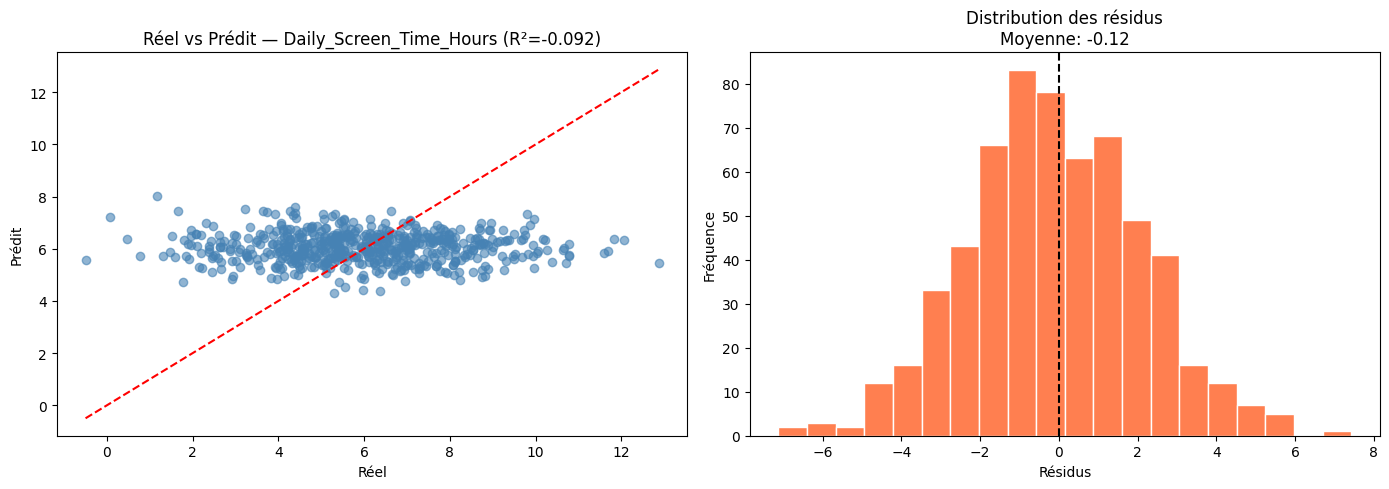

In [225]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.6, color='steelblue')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axes[0].set(xlabel='Réel', ylabel='Prédit',
            title=f'Réel vs Prédit — Daily_Screen_Time_Hours (R²={r2:.3f})')

residus = y_test - y_pred
axes[1].hist(residus, bins=20, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set(xlabel='Résidus', ylabel='Fréquence',
            title=f'Distribution des résidus\nMoyenne: {residus.mean():.2f}')

plt.tight_layout()
plt.show()

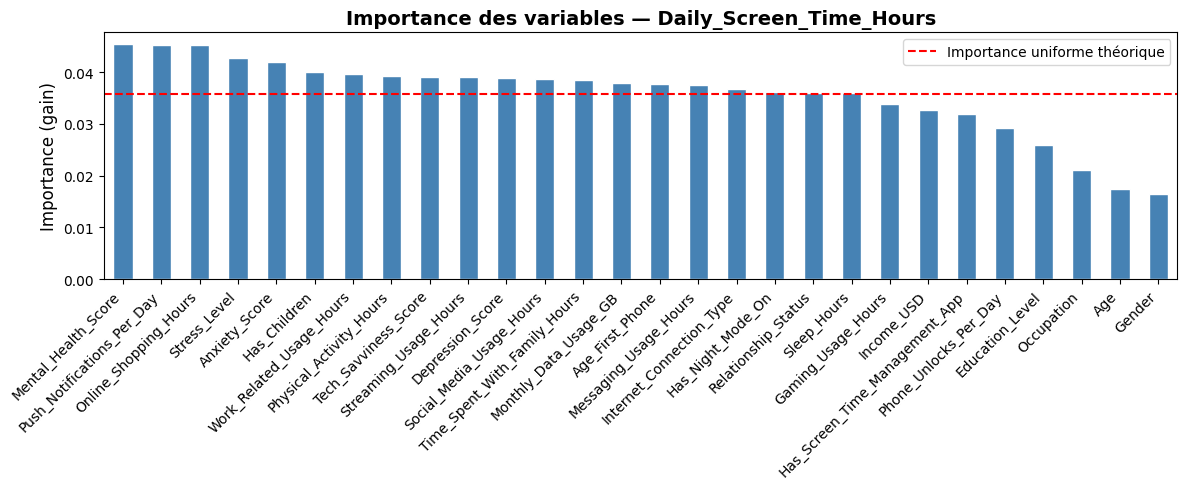

In [226]:
importances = pd.Series(
    xgb.feature_importances_, index=X.columns
).sort_values(ascending=False)

importances.plot(kind='bar', figsize=(12, 5), color='steelblue', edgecolor='white')
plt.ylabel('Importance (gain)', fontsize=12)
plt.title('Importance des variables — Daily_Screen_Time_Hours', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=1 / len(X.columns), color='red', linestyle='--', label='Importance uniforme théorique')
plt.legend()
plt.tight_layout()
plt.show()

### Résultats obtenus

| Modèle | MAE | RMSE | R² |
|---|---|---|---|
| XGBoost — Daily_Screen_Time_Hours | 1.766 | 2.206 | -0.092 |